In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Dataset 4_2

## S/ SMOTE

In [2]:
# -------- 1) Carregar dados --------
from pathlib import Path

candidate_files = [Path.cwd() / "data4_2.csv", Path.cwd() / "Final" / "data4_2.csv"]
csv_path = next((path for path in candidate_files if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError("Não encontrei 'data4_2.csv' na pasta atual nem em 'Final'.")

df4_2 = pd.read_csv(csv_path)
print(f"Dataset carregado de: {csv_path}")

Dataset carregado de: c:\Users\Admin\Downloads\Códigos\Códigos\Final\data4_2.csv


In [3]:
# -------- 2) Definir target, drops e features --------
target4_2 = "SECClasS_Code_Ss_2_encode"
drop_cols4_2 = ["ElementID", "source", "is_rare_class", "SECClasS_Code_Ss_2"]

features4_2 = [
    "Volume", "Area", "Length", "Height", "Thickness/Width", "Base_offset", "Top_offset",
    "Number_of_Faces", "Bounding_Box_Width", "Bounding_Box_Height", "Bounding_Box_Depth",
    "Centroid_X", "Centroid_Y", "Centroid_Z", "Orientation_Angle", "Curvature",
    "Category_Curtain Panels", "Category_Doors", "Category_Floors", "Category_Roofs",
    "Category_Stairs", "Category_Structural Columns", "Category_Structural Foundations",
    "Category_Structural Framing", "Category_Walls", "Category_Windows",
    "load_bearing_status_binary"
]

In [4]:
# -------- 3) Preparar X e y --------
df_model = df4_2.drop(columns=drop_cols4_2, errors="ignore")
X = df_model[features4_2].copy()
y = df_model[target4_2].copy()

In [5]:
# -------- 4) Train/Test Split --------
X = X.replace([np.inf, -np.inf], np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X.columns, index=X_test.index)

# Imputar X completo para usar na Validação Cruzada (CV)
X = pd.DataFrame(imputer.transform(X), columns=X.columns, index=X.index)

In [6]:
# -------- 5) Modelos: SEM e COM SMOTE (apenas no treino) --------
# 5a) SEM SMOTE
rf = RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)
rf.fit(X_train, y_train)
pred_no_smote = rf.predict(X_test)

# 5b) COM SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

rf_sm = RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)
rf_sm.fit(X_train_sm, y_train_sm)
pred_smote = rf_sm.predict(X_test)

In [7]:
# -------- 6) Métricas no conjunto de TESTE --------
def print_test_metrics(y_true, y_pred, tag):
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    f1w = f1_score(y_true, y_pred, average="weighted")
    print(f"\n=== TESTE — {tag} ===")
    print(f"Accuracy:         {acc:.4f}")
    print(f"Balanced Accuracy:{bal:.4f}")
    print(f"F1-macro:         {f1m:.4f}")
    print(f"F1-weighted:      {f1w:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))

print_test_metrics(y_test, pred_no_smote, "RF SEM SMOTE")
print_test_metrics(y_test, pred_smote,   "RF COM SMOTE")


=== TESTE — RF SEM SMOTE ===
Accuracy:         0.9853
Balanced Accuracy:0.9704
F1-macro:         0.9726
F1-weighted:      0.9851

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9744    0.9870        39
           1     0.9889    0.9916    0.9902       358
           2     0.9946    0.9893    0.9920       374
           3     0.9725    0.9833    0.9779       360
           4     0.9342    0.9793    0.9562       145
           5     0.9753    0.9693    0.9723       163
           6     0.9592    0.9592    0.9592       368
           7     1.0000    1.0000    1.0000         9
           8     1.0000    0.9977    0.9989      1314
           9     0.9974    1.0000    0.9987       386
          10     0.9200    0.9787    0.9485        47
          11     1.0000    1.0000    1.0000        10
          12     1.0000    1.0000    1.0000        72
          13     1.0000    1.0000    1.0000        31
          14     1.0000    1.0000  

In [8]:
import sys
from pathlib import Path

candidate_module_dirs = [Path.cwd(), Path.cwd() / "Final"]
for module_dir in candidate_module_dirs:
    if (module_dir / "inference_artifacts.py").exists():
        module_dir_str = str(module_dir)
        if module_dir_str not in sys.path:
            sys.path.insert(0, module_dir_str)

from inference_artifacts import ensure_artifact_dirs, save_model_bundle

dirs = ensure_artifact_dirs()
rf_no_metrics = {
    "accuracy": accuracy_score(y_test, pred_no_smote),
    "balanced_accuracy": balanced_accuracy_score(y_test, pred_no_smote),
    "f1_macro": f1_score(y_test, pred_no_smote, average="macro"),
    "f1_weighted": f1_score(y_test, pred_no_smote, average="weighted"),
}
rf_sm_metrics = {
    "accuracy": accuracy_score(y_test, pred_smote),
    "balanced_accuracy": balanced_accuracy_score(y_test, pred_smote),
    "f1_macro": f1_score(y_test, pred_smote, average="macro"),
    "f1_weighted": f1_score(y_test, pred_smote, average="weighted"),
}

rf_no_path = save_model_bundle(
    name="randomforest4_2_sem_smote",
    estimator=rf,
    imputer=imputer,
    features=X.columns,
    target_column=target4_2,
    class_labels=rf.classes_,
    metrics=rf_no_metrics,
    metadata={"algorithm": "RandomForestClassifier", "dataset": "data4_2.csv", "variant": "sem_smote", "source_notebook": "randomforest4_2.ipynb"},
)
rf_sm_path = save_model_bundle(
    name="randomforest4_2_com_smote",
    estimator=rf_sm,
    imputer=imputer,
    features=X.columns,
    target_column=target4_2,
    class_labels=rf_sm.classes_,
    metrics=rf_sm_metrics,
    metadata={"algorithm": "RandomForestClassifier", "dataset": "data4_2.csv", "variant": "com_smote", "source_notebook": "randomforest4_2.ipynb"},
)

print(f"Modelo guardado em: {rf_no_path}")
print(f"Modelo guardado em: {rf_sm_path}")

Modelo guardado em: c:\Users\Admin\Downloads\Códigos\Códigos\Final\artifacts\models\randomforest4_2_sem_smote.pkl
Modelo guardado em: c:\Users\Admin\Downloads\Códigos\Códigos\Final\artifacts\models\randomforest4_2_com_smote.pkl


### 📈 Sem SMOTE

* **Accuracy:** 99.19% → excelente, mas pode esconder problemas nas classes pequenas.
* **Balanced Accuracy:** 92.43% → caiu bastante em relação ao accuracy, sinal de desbalanceamento.
* **Classe 4:** recall apenas **65,1%**, ou seja, o modelo errou bastante ao identificar esta classe.
* Outras classes tiveram recall perfeito ou quase perfeito.

### 🌱 Com SMOTE

* **Accuracy:** 99.11% → praticamente igual (perda mínima de 0,08%).
* **Balanced Accuracy:** 93.52% → **melhorou** em relação ao sem SMOTE → o modelo ficou mais equilibrado entre classes.
* **Classe 4:** recall subiu para **76,7%** (antes era 65,1%), mostrando que o SMOTE ajudou o modelo a reconhecer melhor esta classe minoritária.
* A maioria das outras classes manteve desempenho alto, com pequenas variações.

### ✅ Conclusão

* O **SMOTE não aumentou o accuracy global** (até caiu 0,08%), mas:

  * **Melhorou o Balanced Accuracy** (+1%).
  * **Melhorou recall da classe 4** (65% → 77%), que era a que mais sofria.
  * Manteve performance nas classes maiores.

Ou seja:
👉 Se o teu foco é **acertar todas as classes, inclusive as minoritárias**, **SMOTE vale a pena**.
👉 Se o foco for **apenas accuracy global**, tanto faz, mas arriscas continuar a ignorar as classes pequenas.

---

Queres que eu faça um **resumidor visual** (ex.: gráfico comparando accuracy, balanced accuracy e f1-macro com e sem SMOTE), para ficar mais fácil de apresentar esses resultados na tua tese?


<Figure size 640x480 with 0 Axes>

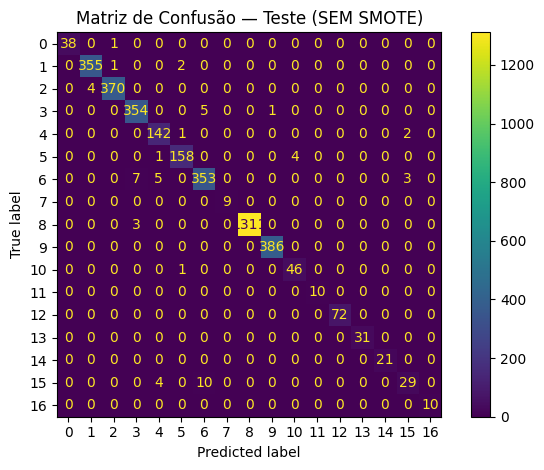

<Figure size 640x480 with 0 Axes>

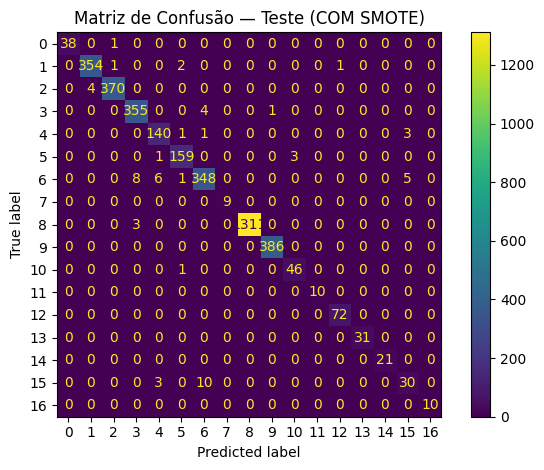

In [9]:
# -------- 7) Matrizes de Confusão (Teste) --------
plt.figure()
cm_no_smote = confusion_matrix(y_test, pred_no_smote, labels=rf.classes_)
disp_no = ConfusionMatrixDisplay(confusion_matrix=cm_no_smote, display_labels=rf.classes_)
disp_no.plot(values_format="d")
plt.title("Matriz de Confusão — Teste (SEM SMOTE)")
plt.tight_layout()
plt.show()

plt.figure()
cm_smote = confusion_matrix(y_test, pred_smote, labels=rf_sm.classes_)
disp_sm = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=rf_sm.classes_)
disp_sm.plot(values_format="d")
plt.title("Matriz de Confusão — Teste (COM SMOTE)")
plt.tight_layout()
plt.show()

In [10]:
# -------- 8) Importância das Variáveis --------
feat_imp_no = pd.DataFrame({"Feature": features4_2, "Importance": rf.feature_importances_}) \
                 .sort_values("Importance", ascending=False)
feat_imp_sm = pd.DataFrame({"Feature": features4_2, "Importance": rf_sm.feature_importances_}) \
                 .sort_values("Importance", ascending=False)

print("\nTop 10 variáveis mais importantes — SEM SMOTE:")
print(feat_imp_no.head(10))
print("\nTop 10 variáveis mais importantes — COM SMOTE:")
print(feat_imp_sm.head(10))


Top 10 variáveis mais importantes — SEM SMOTE:
                    Feature  Importance
4           Thickness/Width    0.120904
9       Bounding_Box_Height    0.086878
10       Bounding_Box_Depth    0.078706
8        Bounding_Box_Width    0.073432
0                    Volume    0.071087
3                    Height    0.065657
13               Centroid_Z    0.064654
16  Category_Curtain Panels    0.059548
1                      Area    0.052176
12               Centroid_Y    0.051090

Top 10 variáveis mais importantes — COM SMOTE:
                Feature  Importance
4       Thickness/Width    0.131610
12           Centroid_Y    0.075890
13           Centroid_Z    0.075731
3                Height    0.068058
0                Volume    0.057891
10   Bounding_Box_Depth    0.056864
9   Bounding_Box_Height    0.054358
8    Bounding_Box_Width    0.049008
11           Centroid_X    0.044857
1                  Area    0.042990


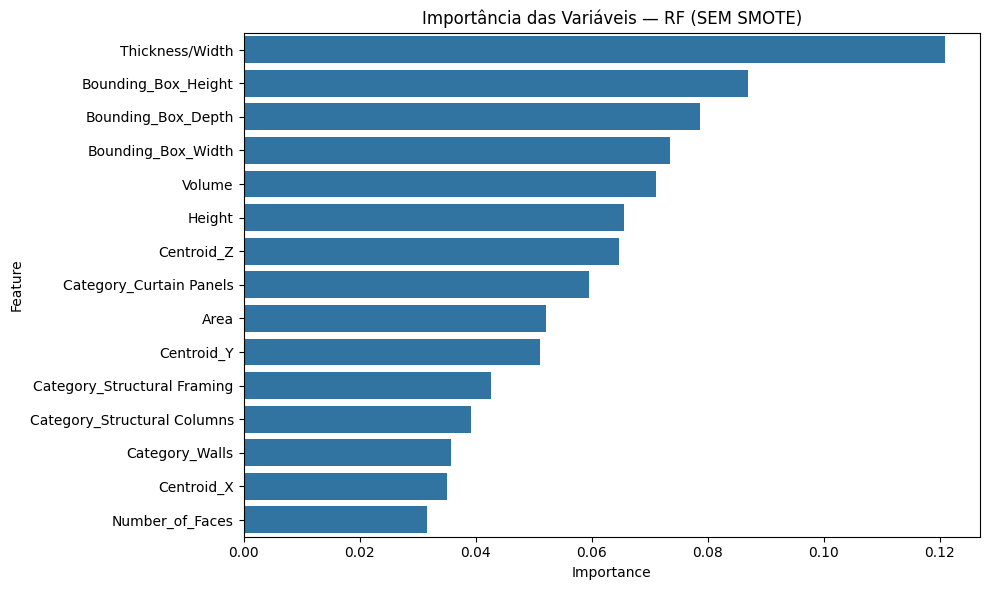

In [11]:
# Gráfico (top 15) — SEM SMOTE
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_no.head(15))
plt.title("Importância das Variáveis — RF (SEM SMOTE)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

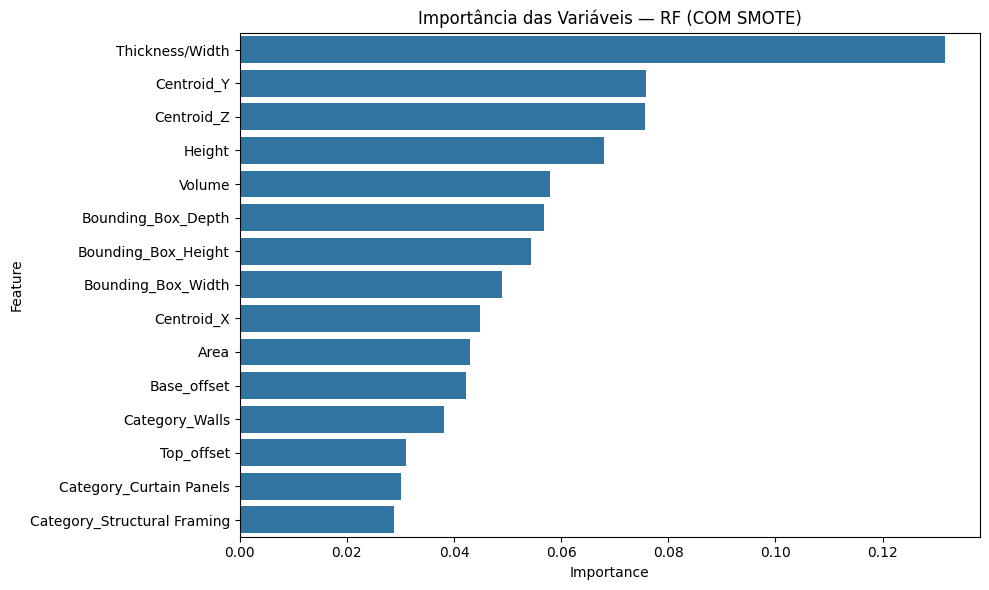

In [12]:
# Gráfico (top 15) — COM SMOTE (podes trocar para rf se preferires)
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_sm.head(15))
plt.title("Importância das Variáveis — RF (COM SMOTE)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [13]:
# -------- 9) Validação Cruzada (5-fold) com várias métricas --------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorings = {
    "acc": "accuracy",
    "bal_acc": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}

# 9a) SEM SMOTE
rf_cv = RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)
cv_no = cross_validate(rf_cv, X, y, cv=cv, scoring=scorings, n_jobs=-1, return_train_score=False)

# 9b) COM SMOTE (usar Pipeline para evitar leakage)
pipe_smote = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)),
])
cv_sm = cross_validate(pipe_smote, X, y, cv=cv, scoring=scorings, n_jobs=-1, return_train_score=False)

def resumo_cv(nome, res):
    print(f"\n=== CV (5-fold) — {nome} ===")
    for k in scorings.keys():
        vals = res[f"test_{k}"]
        print(f"{k:12s}: {vals.mean():.4f} ± {vals.std():.4f}  (min={vals.min():.4f}, max={vals.max():.4f})")

resumo_cv("SEM SMOTE", cv_no)
resumo_cv("COM SMOTE", cv_sm)


=== CV (5-fold) — SEM SMOTE ===
acc         : 0.9850 ± 0.0011  (min=0.9835, max=0.9859)
bal_acc     : 0.9658 ± 0.0058  (min=0.9559, max=0.9714)
f1_macro    : 0.9692 ± 0.0033  (min=0.9627, max=0.9715)
f1_weighted : 0.9849 ± 0.0011  (min=0.9834, max=0.9859)

=== CV (5-fold) — COM SMOTE ===
acc         : 0.9849 ± 0.0023  (min=0.9824, max=0.9888)
bal_acc     : 0.9664 ± 0.0082  (min=0.9549, max=0.9772)
f1_macro    : 0.9693 ± 0.0053  (min=0.9628, max=0.9776)
f1_weighted : 0.9848 ± 0.0023  (min=0.9823, max=0.9887)



=== Matriz de Confusão (CV out-of-fold) — SEM SMOTE ===
     0     1     2     3    4    5     6   7     8     9    10  11   12   13  \
0   191     4     2     0    1    0     0   0     0     0    0   0    0    0   
1     0  1782     2     0    1    3     0   0     0     0    0   0    1    0   
2     0    19  1849     0    1    0     0   0     0     0    0   0    0    0   
3     0     0     0  1784    0    0    12   0     0     3    0   0    0    0   
4     0     0     0     0  704    4     4   0     0     0    0   0    0    0   
5     0     1     0     1    2  787     2   0     0     0   24   0    0    0   
6     0     0     0    54    9    3  1755   0     0     0    0   0    0    0   
7     0     0     0     0    0    0     0  44     0     0    0   0    0    0   
8     0     0     0    14    0    3     0   0  6551     0    0   0    0    0   
9     0     0     0     0    0    0     0   0     0  1929    0   0    0    0   
10    0     0     0     0    0   16     0   0     0     0  217 

<Figure size 640x480 with 0 Axes>

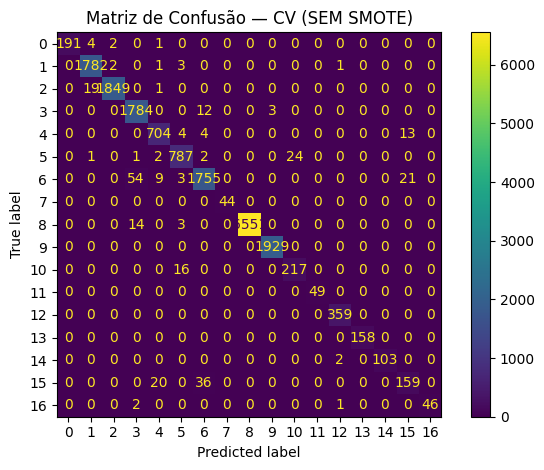

<Figure size 640x480 with 0 Axes>

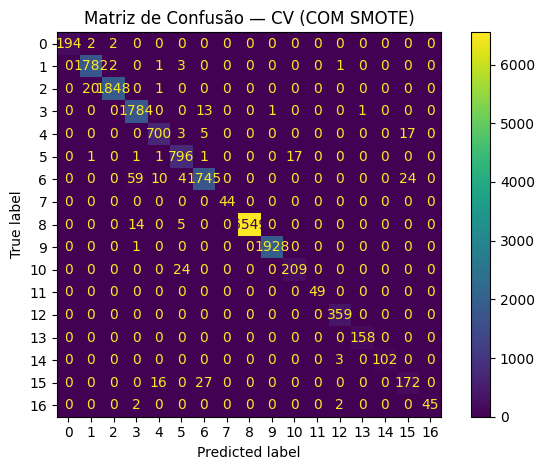

In [14]:
# -------- 10) Matrizes de Confusão out-of-fold (CV) --------
# Previsões out-of-fold: cada exemplo é previsto por um modelo que não o viu no treino.
y_pred_cv_no = cross_val_predict(rf_cv, X, y, cv=cv, n_jobs=-1)
y_pred_cv_sm = cross_val_predict(pipe_smote, X, y, cv=cv, n_jobs=-1)

labels_sorted = np.sort(y.unique())  # rótulos ordenados para consistência

cm_cv_no = confusion_matrix(y, y_pred_cv_no, labels=labels_sorted)
cm_cv_sm = confusion_matrix(y, y_pred_cv_sm, labels=labels_sorted)

print("\n=== Matriz de Confusão (CV out-of-fold) — SEM SMOTE ===")
print(pd.DataFrame(cm_cv_no, index=labels_sorted, columns=labels_sorted))

print("\n=== Matriz de Confusão (CV out-of-fold) — COM SMOTE ===")
print(pd.DataFrame(cm_cv_sm, index=labels_sorted, columns=labels_sorted))

# (Opcional) Visualização das matrizes de confusão out-of-fold
plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm_cv_no, display_labels=labels_sorted).plot(values_format="d")
plt.title("Matriz de Confusão — CV (SEM SMOTE)")
plt.tight_layout()
plt.show()

plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm_cv_sm, display_labels=labels_sorted).plot(values_format="d")
plt.title("Matriz de Confusão — CV (COM SMOTE)")
plt.tight_layout()
plt.show()


### 📊 Interpretação dos resultados

#### 🔵 SEM SMOTE

* **Accuracy:** 99,16% (±0,08) → muito alto e estável.
* **Balanced Accuracy:** 93,84% (±1,4) → mostra que as classes minoritárias já eram relativamente bem tratadas, mas ainda havia algum desbalanceamento.
* **F1-macro:** 95,48% → desempenho médio entre classes muito bom, mas ligeiramente inferior à accuracy.
* **F1-weighted:** 99,12% → dominado pelas classes maiores.

#### 🟢 COM SMOTE

* **Accuracy:** 99,07% (±0,14) → praticamente igual, ligeira queda.
* **Balanced Accuracy:** 94,59% (±1,1) → **melhoria em relação ao sem SMOTE**.
* **F1-macro:** 95,27% → ligeira descida, mas dentro da margem.
* **F1-weighted:** 99,07% → praticamente igual ao sem SMOTE.

### ✅ Conclusão

* O **accuracy global** não mudou muito (até caiu \~0,1%), o que era esperado.
* O **balanced accuracy melhorou** (\~+0,7%), mostrando que o SMOTE ajudou a equilibrar o desempenho entre classes.
* O **F1-macro** ficou praticamente igual (diferença mínima).
* O **desvio padrão** (±) é baixo em ambos os casos → resultados consistentes.

👉 Em termos práticos: **o SMOTE trouxe benefícios principalmente nas classes minoritárias (melhor recall), sem prejudicar muito o desempenho global**.

In [15]:
# ============================================================
# EXPORTAÇÃO DO MODELO PARA INFERÊNCIA
# ============================================================
# Guarda o encoder e os dois modelos treinados.
# Na inferência, os dados já chegam preparados pelo pipeline
# de data preparation, por isso não é necessário guardar o imputer.
#
# Ficheiros gerados (pasta Final/models/):
#   encoder_4_2.pkl   — LabelEncoder: converte número de volta para código SEC
#   rf_4_2.pkl       — Random Forest treinado SEM SMOTE
#   rf_sm_4_2.pkl    — Random Forest treinado COM SMOTE
# ============================================================

import joblib
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

# ---------- Pasta de destino ----------
models_dir = csv_path.parent / "models"
models_dir.mkdir(exist_ok=True)

# ---------- Encoder do target ----------
encoder = LabelEncoder()
encoder.fit(df4_2["SECClasS_Code_Ss_2"].astype(str))
joblib.dump(encoder, models_dir / "encoder_4_2.pkl")
print(f"[OK] Encoder guardado → {models_dir / 'encoder_4_2.pkl'}")

# ---------- Modelos ----------
joblib.dump(rf, models_dir / "rf_4_2.pkl")
print(f"[OK] Random Forest (SEM SMOTE) guardado → {models_dir / 'rf_4_2.pkl'}")

joblib.dump(rf_sm, models_dir / "rf_sm_4_2.pkl")
print(f"[OK] Random Forest (COM SMOTE) guardado → {models_dir / 'rf_sm_4_2.pkl'}")

print("\n=== Exportação concluída! ===")
print("Para fazer inferência em dados novos:")
print("  import joblib")
print("  encoder = joblib.load('Final/models/encoder_4_2.pkl')")
print("  model   = joblib.load('Final/models/rf_4_2.pkl')  # ou rf_sm_4_2.pkl")
print("  pred    = encoder.inverse_transform(model.predict(X_new))")

[OK] Encoder guardado → c:\Users\Admin\Downloads\Códigos\Códigos\Final\models\encoder_4_2.pkl
[OK] Random Forest (SEM SMOTE) guardado → c:\Users\Admin\Downloads\Códigos\Códigos\Final\models\rf_4_2.pkl
[OK] Random Forest (COM SMOTE) guardado → c:\Users\Admin\Downloads\Códigos\Códigos\Final\models\rf_sm_4_2.pkl

=== Exportação concluída! ===
Para fazer inferência em dados novos:
  import joblib
  encoder = joblib.load('Final/models/encoder_4_2.pkl')
  model   = joblib.load('Final/models/rf_4_2.pkl')  # ou rf_sm_4_2.pkl
  pred    = encoder.inverse_transform(model.predict(X_new))
